In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from helpers import *
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_DIR = "../planetsdataset"

In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [4]:
train_dataset, valid_dataset, test_dataset, class_names = load_datasets(DATASET_DIR, IMG_SIZE, BATCH_SIZE)
num_classes = len(class_names)

Found 2430 files belonging to 12 classes.
Found 666 files belonging to 12 classes.
Found 341 files belonging to 12 classes.


In [5]:
num_classes = len(class_names)
#3 sets of convolution with pooling, each more complex
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       7

In [6]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [7]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
54/76 [====================>.........] - ETA: 2s - loss: 1.6388 - accuracy: 0.4369

2026-04-19 21:00:45.806952: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 134ms/step - loss: 1.4657 - accuracy: 0.4893 - val_loss: 0.7675 - val_accuracy: 0.7703
Epoch 2/20
54/76 [====================>.........] - ETA: 3s - loss: 0.7453 - accuracy: 0.7743

2026-04-19 21:00:57.719692: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 13s 153ms/step - loss: 0.7124 - accuracy: 0.7864 - val_loss: 0.5521 - val_accuracy: 0.8168
Epoch 3/20
54/76 [====================>.........] - ETA: 2s - loss: 0.5416 - accuracy: 0.8333

...

76/76 [==============================] - 20s 235ms/step - loss: 0.1409 - accuracy: 0.9551 - val_loss: 0.3533 - val_accuracy: 0.9249
Epoch 10/20
54/76 [====================>.........] - ETA: 3s - loss: 0.1295 - accuracy: 0.9583

2026-04-19 21:03:41.522335: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 15s 184ms/step - loss: 0.1318 - accuracy: 0.9551 - val_loss: 0.3683 - val_accuracy: 0.9099
Epoch 11/20
54/76 [====================>.........] - ETA: 4s - loss: 0.1201 - accuracy: 0.9583

2026-04-19 21:03:57.063514: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 17s 204ms/step - loss: 0.1160 - accuracy: 0.9597 - val_loss: 0.5947 - val_accuracy: 0.8859


In [8]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

11/11 [==============================] - 2s 46ms/step - loss: 0.2792 - accuracy: 0.9150
Test loss: 0.2792418897151947
Test accuracy: 0.9149560332298279


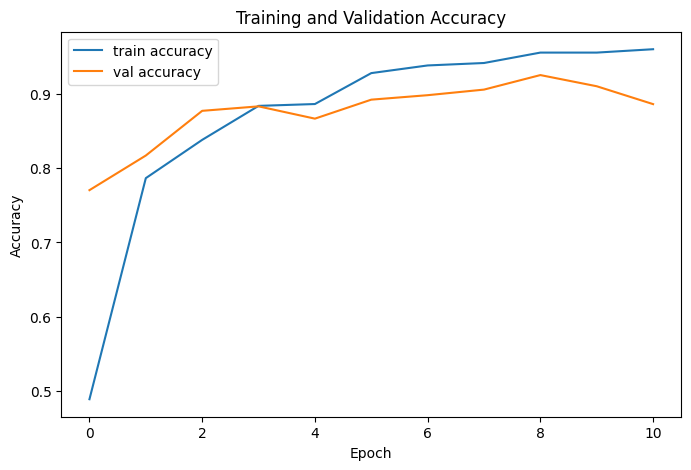

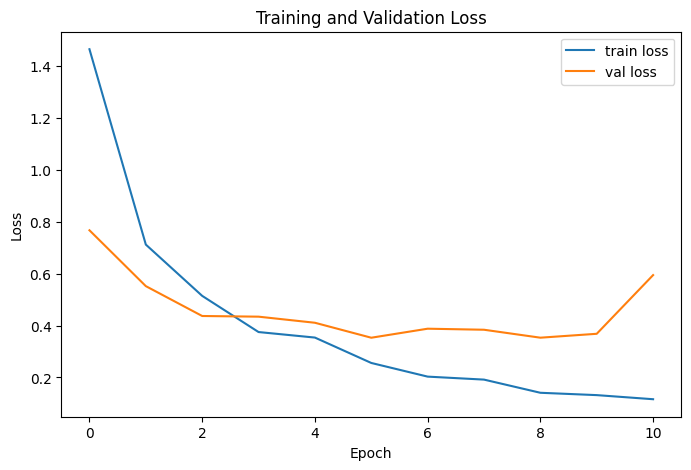

In [9]:
plot_history(history)

In [10]:
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
cm = confusion_matrix(y_true, y_pred)

11/11 [==============================] - 1s 39ms/step


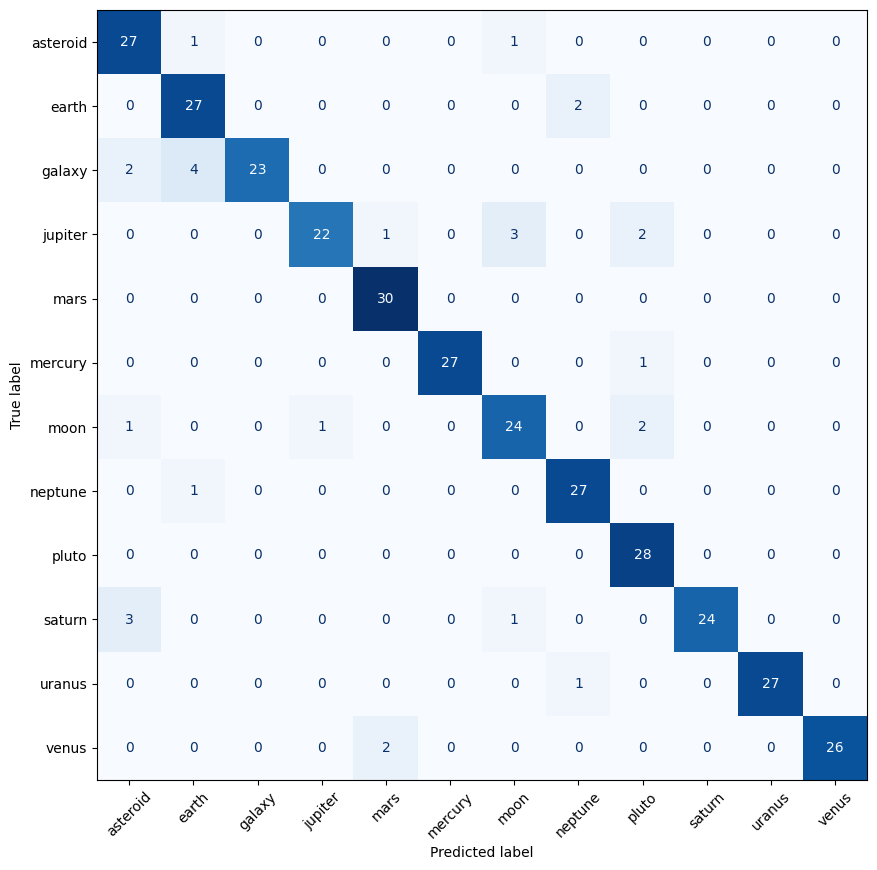

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()